In [1]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, print_wise, get_lagplot
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.regression import linear_encoding, dyn_linear_encoding
from useful_stuff.general_utils.II import dynInformationImbalance
from project_specific_utils.dataloader import load_meg_data, load_eyetracking_data
from image_processing.gaze_dep_models import save_pixelwise_luminance, save_OF


In [2]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 3
    run = 1
    neu_fs = 100
    gaze_fs = 50
    sq_side = 250
    downsampled_sq_size = 50
    sensors_group = 'occ'
    model_name = "pixelwise_luminance"
    time_points = 100
    pseudotrials_n = 500
    max_lag=100
cfg = Cfg()

In [3]:
def load_ICA_meg_data(paths: dict[str: str], sub_num: int, run: int, sensors_group: str, fs: float):
    file_path = f"{paths['data_path']}/data/sub{sub_num:03d}/preprocessed_eyeICA/sub{sub_num:03d}_{sensors_group}_{fs}Hz_MNN0_badmuscle0_badlowfreq1_badsegint1_badcomp1.mat"    
    data = loadmat(file_path)
    labels = [str(x[0]) for x in data['label'].flatten()]
    data_neural = data['data_final'][run-1][0]
    data_neural = TimeSeries(data_neural, fs)
    return data_neural, labels
# EOF

In [5]:
neu_rep1, labels1 = load_meg_data(paths, cfg.sub_num, cfg.run, cfg.sensors_group, cfg.neu_fs)
neu_rep1.z_score_feats()
neu_rep2, labels2 = load_meg_data(paths, cfg.sub_num, cfg.run+3, cfg.sensors_group, cfg.neu_fs)
neu_rep2.z_score_feats()
gaze_rep1, _ = load_eyetracking_data(paths, cfg.sub_num, cfg.run, cfg.gaze_fs, xy=True)
gaze_rep1.z_score_feats()
# gaze_rep1.resample(cfg.neu_fs)
# print(gaze_rep1.get_array().shape)

array([[-1.41159514, -1.38178685, -1.26524247, ...,  0.522323  ,
         0.5042304 ,  0.50171606],
       [-0.78775998, -0.66992168, -0.7482698 , ..., -0.23637426,
        -0.13834903, -0.12713661]], shape=(2, 43693))

In [6]:
regr_obj = dyn_linear_encoding('lr', 'same', 20)
y_regress_out, _ = regr_obj.delay_embed_PCR_regress_out(gaze_rep1, neu_rep1, (-100, 100), PCs_to_keep=50, pad_mode='edge', crop_end=True)


In [35]:
gaze_projected = (gaze_for_pca @ pca_obj.components_.T).T
print(gaze_projected.shape)
gaze_projected = TimeSeries(gaze_projected, cfg.gaze_fs)
print(gaze_projected.get_array().shape)
gaze_projected.resample(cfg.neu_fs)
print(gaze_projected.get_array().shape)

(40, 43693)
(40, 43693)
(40, 87386)


In [36]:
gaze_projected.shape(), neu_for_regression.shape()

((40, 87386), (41, 87484))

In [50]:
dyn_regr_obj = dyn_linear_encoding('ridge', 'same', 20)
neu_for_regression = TimeSeries(neu_rep1[:len(gaze_projected)], cfg.neu_fs)
y_regress_out = dyn_regr_obj.pointwise_regress_out(gaze_projected, neu_for_regression, regression_type="lr")

18:47:35 - Switching to LinearRegression()
18:47:35 - Switching back to RidgeCV(alphas=array([1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01,
       1.e+02, 1.e+03]))


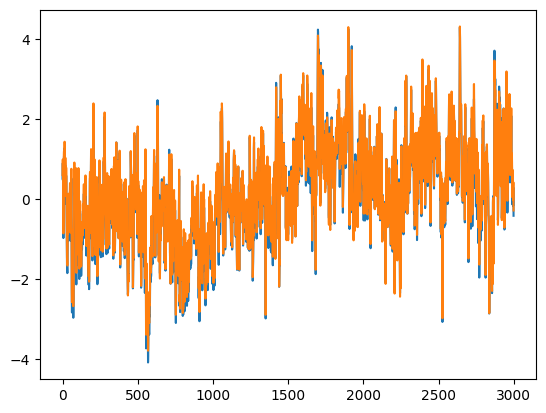

In [7]:
plt.plot(neu_rep1.get_array()[0, :3000])
plt.plot(y_regress_out.get_array()[0, :3000])
# plt.plot(gaze_projected.get_array()[0, :3000])

In [8]:
gaze_rep1.resample(cfg.neu_fs)
model = dyn_linear_encoding('ridge', 'kf', cfg.max_lag, score_type="r2", n_splits=2)
X, Y = TimeSeries(gaze_rep1.get_array()[:,:,np.newaxis], neu_rep1.get_fs()), TimeSeries(y_regress_out.get_array()[:,:,np.newaxis], y_regress_out.get_fs())
s = model.crossvalidate_general_dyn(X, Y)
os.system('afplay /System/Library/Sounds/Ping.aiff')

0

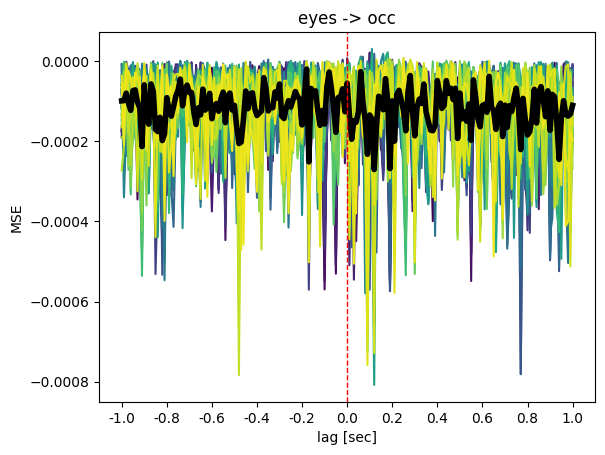

In [9]:
import matplotlib.pyplot as plt
import numpy as np

data = s.get_array()
n_lines = data.shape[0]
tick_step = 20
cmap = plt.get_cmap("viridis")  # choose your cmap
max_lag = cfg.max_lag
fs = s.get_fs()
ticks = np.arange(-max_lag, max_lag + 1, tick_step)
ticks_labels = np.round(ticks / fs, 2)
ticks+= max_lag
for i in range(n_lines):
    color = cmap(i / n_lines)
    plt.plot(data.T[:, i], color=color, label=labels1[i])

# mean in black (on top)
# ticks = np.arange(-cfg.max_lag-1, cfg.max_lag+1, tick_step) + cfg.max_lag
# ticks_labels = np.round(np.arange(-cfg.max_lag/s.get_fs(), (cfg.max_lag+1)/s.get_fs(), tick_step/s.get_fs()), 2)
plt.plot(data.mean(axis=0), linewidth=4, color="k")
plt.xticks(ticks, ticks_labels)
plt.axvline(data.shape[1]//2, color="r", linestyle="--", linewidth=1)
plt.title(f"eyes -> {cfg.sensors_group}")
plt.ylabel("MSE")
plt.xlabel("lag [sec]");

# plt.legend(fontsize=6)